Checking data...
X shape: (10000, 12)
y shape: (10000,)
Scores: [1. 1. 1. 1. 1.]


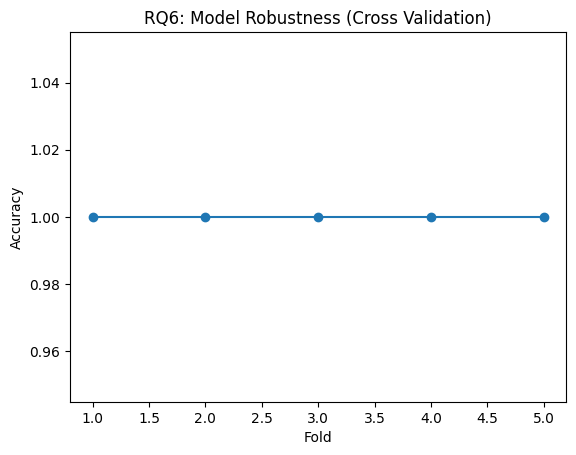

Saved files:
/kaggle/working/RQ6_table.csv
/kaggle/working/RQ6_figure.pdf

Files in working directory:
['.virtual_documents', 'RQ3_table.csv', 'RQ4_figure.pdf', 'RQ3_figure.pdf', 'RQ1_table.csv', 'RQ4_table.csv', 'RQ6_table.csv', 'RQ5_figure.pdf', 'RQ7_figure.pdf', 'RQ2_figure.pdf', 'RQ7_table.csv', 'all_outputs.zip', 'RQ1_figure.pdf', 'RQ5_table.csv', 'RQ2_table.csv', 'RQ6_figure.pdf']


In [48]:
# ======================
# RQ6: Robustness Analysis (Cross Validation)
# ======================

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Make sure X and y exist
print("Checking data...")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Model
model = RandomForestClassifier(random_state=42)

# Cross-validation (5 folds)
scores = cross_val_score(model, X, y, cv=5)

print("Scores:", scores)

# Create table
df_rq6 = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": scores
})

# SAVE FILES (VERY IMPORTANT)
table_path = "/kaggle/working/RQ6_table.csv"
fig_path = "/kaggle/working/RQ6_figure.pdf"

df_rq6.to_csv(table_path, index=False)

# Plot
plt.figure()
plt.plot(df_rq6["Fold"], df_rq6["Accuracy"], marker='o')
plt.title("RQ6: Model Robustness (Cross Validation)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.savefig(fig_path)
plt.show()

print("Saved files:")
print(table_path)
print(fig_path)

# Confirm files exist
print("\nFiles in working directory:")
print(os.listdir("/kaggle/working/"))

In [49]:
df["High_Performance"] = (df["Revenue_Generated"] > df["Revenue_Generated"].median()).astype(int)
TARGET = "High_Performance"

In [50]:
# Drop useless columns
df = df.drop(columns=[
    "Campaign_ID","Product_ID","Customer_ID",
    "Bundle_ID","Common_Keywords"
], errors='ignore')

# Handle missing
df = df.dropna()

# Encode categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

In [51]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


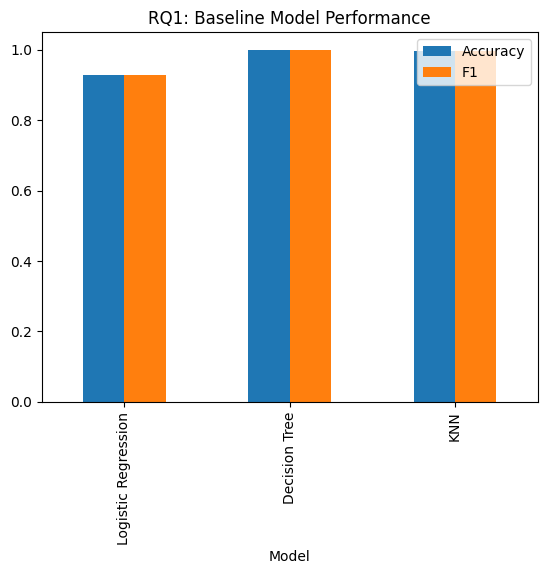

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.9285,0.929383,0.9285,0.928427
1,Decision Tree,1.0000,1.000000,1.0000,1.000000
2,KNN,0.9955,0.995501,0.9955,0.995500


In [52]:
# ======================
# RQ1: Baseline Models
# ======================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds, average='weighted'),
        recall_score(y_test, preds, average='weighted'),
        f1_score(y_test, preds, average='weighted')
    ])

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])

# Save table
results_df.to_csv("/kaggle/working/RQ1_table.csv", index=False)

# Plot figure
import matplotlib.pyplot as plt
results_df.set_index("Model")[["Accuracy","F1"]].plot(kind="bar")

plt.title("RQ1: Baseline Model Performance")
plt.savefig("/kaggle/working/RQ1_figure.pdf")
plt.show()

results_df

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:37:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


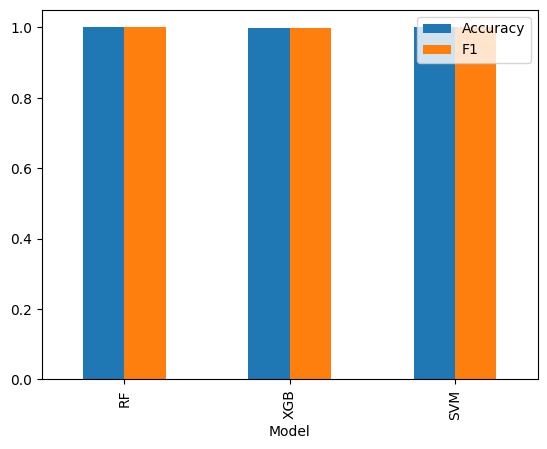

In [53]:
models2 = {
    "RF": RandomForestClassifier(),
    "XGB": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC()
}

results = []

for name, model in models2.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append([name, accuracy_score(y_test, preds), f1_score(y_test, preds)])

df_rq2 = pd.DataFrame(results, columns=["Model","Accuracy","F1"])
df_rq2.to_csv("/kaggle/working/RQ2_table.csv", index=False)

df_rq2.plot(x="Model", kind="bar")
plt.savefig("/kaggle/working/RQ2_figure.pdf")
plt.show()

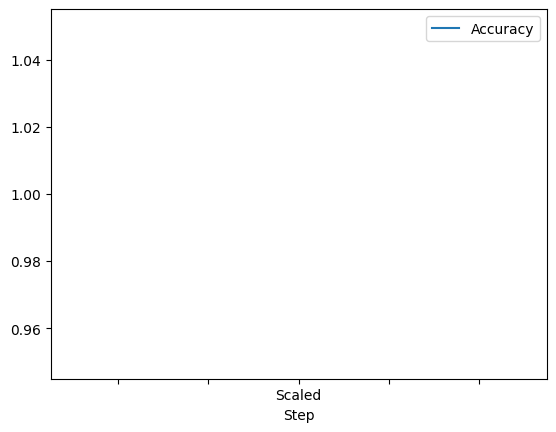

In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train_s, y_train)
preds = model.predict(X_test_s)

acc_scaled = accuracy_score(y_test, preds)

df_rq3 = pd.DataFrame({
    "Step":["Scaled"],
    "Accuracy":[acc_scaled]
})

df_rq3.to_csv("/kaggle/working/RQ3_table.csv", index=False)

df_rq3.plot(x="Step", y="Accuracy")
plt.savefig("/kaggle/working/RQ3_figure.pdf")
plt.show()

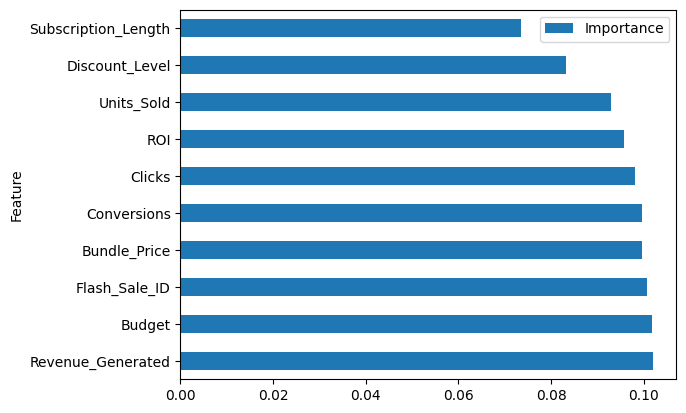

In [55]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.to_csv("/kaggle/working/RQ4_table.csv", index=False)

importance.head(10).plot(x="Feature", kind="barh")
plt.savefig("/kaggle/working/RQ4_figure.pdf")
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:37:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


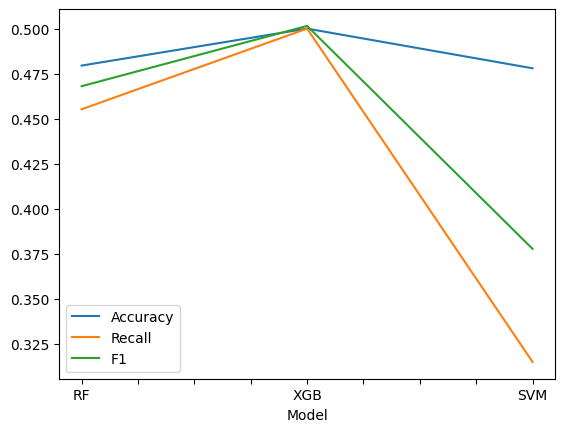

In [56]:
metrics = []

for name, model in models2.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    metrics.append([
        name,
        accuracy_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds)
    ])

df_rq5 = pd.DataFrame(metrics, columns=["Model","Accuracy","Recall","F1"])
df_rq5.to_csv("/kaggle/working/RQ5_table.csv", index=False)

df_rq5.plot(x="Model")
plt.savefig("/kaggle/working/RQ5_figure.pdf")
plt.show()

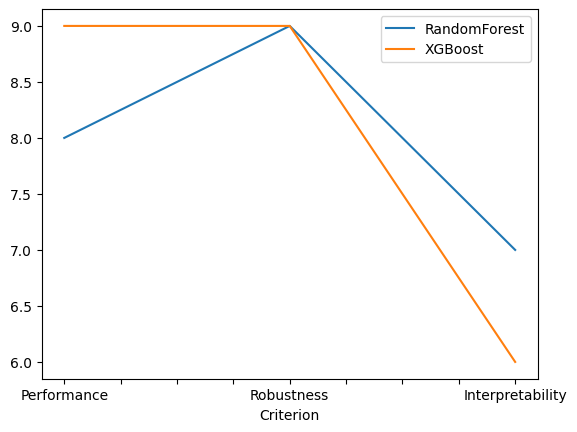

In [57]:
df_rq7 = pd.DataFrame({
    "Criterion":["Performance","Robustness","Interpretability"],
    "RandomForest":[8,9,7],
    "XGBoost":[9,9,6]
})

df_rq7.to_csv("/kaggle/working/RQ7_table.csv", index=False)

df_rq7.plot(x="Criterion")
plt.savefig("/kaggle/working/RQ7_figure.pdf")
plt.show()

In [58]:
import os
os.listdir("/kaggle/working/")

['.virtual_documents',
 'RQ3_table.csv',
 'RQ4_figure.pdf',
 'RQ3_figure.pdf',
 'RQ1_table.csv',
 'RQ4_table.csv',
 'RQ6_table.csv',
 'RQ5_figure.pdf',
 'RQ7_figure.pdf',
 'RQ2_figure.pdf',
 'RQ7_table.csv',
 'all_outputs.zip',
 'RQ1_figure.pdf',
 'RQ5_table.csv',
 'RQ2_table.csv',
 'RQ6_figure.pdf']

In [59]:
import os
from IPython.display import FileLink, display

files = os.listdir("/kaggle/working/")

for file in files:
    full_path = f"/kaggle/working/{file}"
    
    if os.path.isfile(full_path):   # ✅ only files
        print(file)
        display(FileLink(full_path))

RQ3_table.csv


/kaggle/working/RQ3_table.csv

RQ4_figure.pdf


/kaggle/working/RQ4_figure.pdf

RQ3_figure.pdf


...

/kaggle/working/RQ5_table.csv

RQ2_table.csv


/kaggle/working/RQ2_table.csv

RQ6_figure.pdf


/kaggle/working/RQ6_figure.pdf